# **Taller Riesgo y Análisis de Fraude Bancario**

**Integrantes**
- 

- Nicoll Quesada
- Valentina
- Joel Felipe Alba Acosta

**Librerias**
-

In [14]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp
import json
import squarify
from sklearn.impute import KNNImputer

# **1. Importación Base de Datos**

In [2]:
df = pd.read_csv("transacciones_banco.csv")

In [5]:
df.head()

,ID_Transaccion,Fecha,Cliente_ID,Monto_COP,Tipo_Transaccion,Ciudad,Estado,Dias_Cliente,Monto_Historico_Promedio
0,TRX001,2024-01-15,CLI0042,450000.0,Transferencia,Bogotá,Completada,89.0,850000
1,TRX002,2024-01-16,CLI0108,2500000.0,Retiro,Medellín,Completada,156.0,2400000
2,TRX003,2024-02-31,CLI0256,-850000.0,Transferencia,Cali,Rechazada,45.0,1200000
3,TRX004,2024-01-18,CLI0512,1200000.0,Pago,Bogotá,Completada,234.0,1150000
4,TRX005,2024-01-19,NaN,750000.0,Retiro,NaN,Pendiente,NaN,980000


## **2. Análisis General Base de Datos**

## **2.1 Información General**

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID_Transaccion            500 non-null    str    
 1   Fecha                     499 non-null    str    
 2   Cliente_ID                357 non-null    str    
 3   Monto_COP                 479 non-null    float64
 4   Tipo_Transaccion          500 non-null    str    
 5   Ciudad                    498 non-null    str    
 6   Estado                    500 non-null    str    
 7   Dias_Cliente              357 non-null    float64
 8   Monto_Historico_Promedio  500 non-null    int64  
dtypes: float64(2), int64(1), str(6)
memory usage: 35.3 KB


## **2.2 Datos Únicos por Columna**

In [ ]:
for c in df.columns:
    print(f"La columna {c} tiene {df[c].nunique()} valores únicos")

La columna ID_Transaccion tiene 500
La columna Fecha tiene 86
La columna Cliente_ID tiene 8
La columna Monto_COP tiene 60
La columna Tipo_Transaccion tiene 3
La columna Ciudad tiene 5
La columna Estado tiene 3
La columna Dias_Cliente tiene 7
La columna Monto_Historico_Promedio tiene 34


## **2.3 Datos Faltantes por Columna**

In [6]:
for c in df.columns:
    print(f"La columna {c} tiene {df[c].isnull().sum()} valores faltantes")

La columna ID_Transaccion tiene 0 valores faltantes
La columna Fecha tiene 1 valores faltantes
La columna Cliente_ID tiene 143 valores faltantes
La columna Monto_COP tiene 21 valores faltantes
La columna Tipo_Transaccion tiene 0 valores faltantes
La columna Ciudad tiene 2 valores faltantes
La columna Estado tiene 0 valores faltantes
La columna Dias_Cliente tiene 143 valores faltantes
La columna Monto_Historico_Promedio tiene 0 valores faltantes


In [7]:
df.head(20)

,ID_Transaccion,Fecha,Cliente_ID,Monto_COP,Tipo_Transaccion,Ciudad,Estado,Dias_Cliente,Monto_Historico_Promedio
0,TRX001,2024-01-15,CLI0042,450000.0,Transferencia,Bogotá,Completada,89.0,850000
1,TRX002,2024-01-16,CLI0108,2500000.0,Retiro,Medellín,Completada,156.0,2400000
2,TRX003,2024-02-31,CLI0256,-850000.0,Transferencia,Cali,Rechazada,45.0,1200000
3,TRX004,2024-01-18,CLI0512,1200000.0,Pago,Bogotá,Completada,234.0,1150000
4,TRX005,2024-01-19,NaN,750000.0,Retiro,NaN,Pendiente,NaN,980000
5,TRX006,2024-01-20,CLI0315,125000000.0,Transferencia,Bogotá,Completada,12.0,2100000
6,TRX007,2024-01-21,CLI0789,890000.0,Pago,Medellín,Completada,567.0,920000
7,TRX008,2024-01-22,CLI0042,0.0,Transferencia,Bogotá,Completada,89.0,850000
8,TRX009,NaN,CLI0198,3400000.0,Retiro,Bogotá,Completada,234.0,3200000
9,TRX010,2023-11-05,CLI0654,650000.0,Transferencia,Cartagena,Completada,178.0,580000


In [9]:
df[df['Cliente_ID'] == 'CLI0042']['Dias_Cliente'].unique()

array([89.])

# **3. Análisis Exploratorio (EDA)**

In [11]:
def resumen_estadistico_df(df, columna):
    """
    Calcula estadísticas descriptivas avanzadas para una columna numérica
    de un DataFrame y devuelve un DataFrame con los resultados.

    Parámetros:
        df (pd.DataFrame): DataFrame de entrada
        columna (str): Nombre de la columna numérica

    Retorna:
        pd.DataFrame: DataFrame con las métricas estadísticas
    """
    
    if columna not in df.columns:
        raise ValueError(f"La columna '{columna}' no existe en el DataFrame.")
    
    if not np.issubdtype(df[columna].dtype, np.number):
        raise TypeError(f"La columna '{columna}' no es numérica.")
    
    serie = df[columna].dropna()
    
    media = serie.mean()
    std = serie.std()
    
    resultados = {
        "media": media,
        "mediana": serie.median(),
        "q1": serie.quantile(0.25),
        "q3": serie.quantile(0.75),
        "min": serie.min(),
        "max": serie.max(),
        "rango": serie.max() - serie.min(),
        "coef_variacion": std / media if media != 0 else np.nan,
        "varianza": serie.var(),
        "std": std,
        "asimetria": serie.skew(),
        "curtosis": serie.kurt()
    }
    
    # Convertir el diccionario a DataFrame (una fila)
    df_resultado = pd.DataFrame(resultados, index=[columna])
    
    return df_resultado

def plot_numeric_data(column):

    palette = sns.color_palette("Set2", 3)
    colors = np.random.choice(range(len(palette)), 3, replace=False)

    fig, ax = plt.subplots(1, 3, figsize=(14,4))

    fig.suptitle(f"Análisis Gráfico {column}", fontsize=12, fontweight="bold")

    sns.histplot(df[column], kde=False, ax=ax[0], color=palette[colors[0]])
    ax[0].set_title(f"Histograma de {column}")
    ax[0].set_xlabel(column)
    ax[0].set_ylabel("Frecuencia")

    sns.boxplot(x=df[column], ax=ax[1], color=palette[colors[1]])
    ax[1].set_title(f"Boxplot de {column}")
    ax[1].set_xlabel(column)
    ax[1].set_ylabel("")

    sns.kdeplot(x=df[column], ax=ax[2], color=palette[colors[2]], linewidth=2)
    ax[2].set_title(f"Densidad (KDE) de {column}")
    ax[2].set_xlabel(column)
    ax[2].set_ylabel("Densidad")

    plt.tight_layout()
    plt.show()

def treemap_categorica(df, columna, title=None):
    """
    Genera un treemap para una variable categórica.

    Parámetros:
        df (pd.DataFrame): DataFrame de entrada
        columna (str): Columna categórica a graficar
        title (str, opcional): Título del gráfico
    """
    if columna not in df.columns:
        raise ValueError(f"La columna '{columna}' no existe en el DataFrame.")
    
    # Contar frecuencia de cada categoría
    conteo = df[columna].value_counts()
    
    # Preparar colores
    colores = plt.cm.tab20.colors  # paleta de 20 colores
    
    # Crear treemap
    plt.figure(figsize=(12,6))
    squarify.plot(
        sizes=conteo.values, 
        label=[f"{cat}\n{val}" for cat, val in zip(conteo.index, conteo.values)],
        color=colores[:len(conteo)],
        alpha=0.8
    )
    plt.axis('off')
    if title:
        plt.title(title, fontsize=16)
    plt.show()

## **3.1 Columnas Númericas**

### **3.1.1 Monto COP**

In [ ]:
resultado_final = pd.concat(
    [resumen_estadistico_df(df, c).assign(Variable=c) for c in columns],
    axis=0,
    ignore_index=True
)
resultado_final

,media,mediana,q1,q3,min,max,rango,coef_variacion,varianza,std,asimetria,curtosis,Variable
0,2.105971e+06,1800000.0,1100000.0,2300000.0,-850000.0,125000000.0,125850000.0,2.851852,3.607105e+13,6.005918e+06,18.761490,373.882789,Monto_COP
1,1.821261e+02,156.0,45.0,234.0,12.0,567.0,555.0,0.948757,2.985757e+04,1.727934e+02,1.362516,0.768819,Dias_Cliente
2,1.423140e+06,1200000.0,920000.0,2100000.0,550000.0,3200000.0,2650000.0,0.438860,3.900749e+11,6.245598e+05,0.392335,-1.240937,Monto_Historico_Promedio


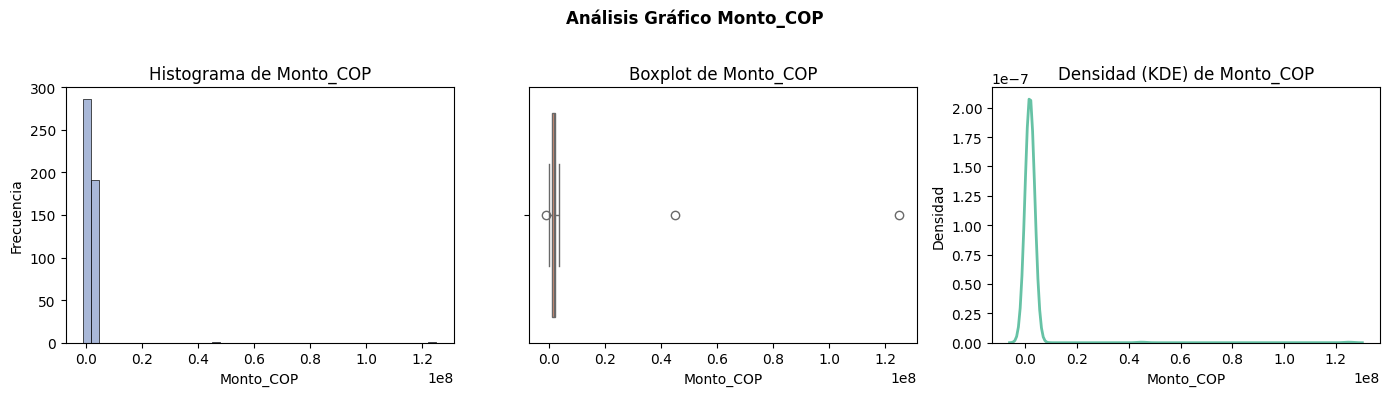

In [16]:
plot_numeric_data('Monto_COP')

In [18]:
resumen_estadistico_df(df,'Dias_Cliente')

,media,mediana,q1,q3,min,max,rango,coef_variacion,varianza,std,asimetria,curtosis
Dias_Cliente,182.12605,156.0,45.0,234.0,12.0,567.0,555.0,0.948757,29857.571145,172.793435,1.362516,0.768819


In [ ]:
plot_numeric_data('Dias_Cliente')